In [1]:
import xarray as xr
import numpy as np
import numpy.ma as ma
import glob
import so_ase as so
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import pyfesom2 as pf
from dask.diagnostics import ProgressBar
from scipy.interpolate import griddata
ProgressBar().register()

/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/pyfesom2/ut.py:15: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/pyfesom2/climatology.py:14: UserWarning: The seawater library is deprecated! Please use gsw instead.
  import seawater as sw


osgeo is not installed, conversion to Geo formats like Geotiff (fesom2GeoFormat) will not work.


## General Settings

In [2]:
# --- Paths To Model Output ---
src_path = '/work/ab0995/a270186/model_simulations/fesom2/ARC01/'

# --- Path To Mesh Diagnostics
mesh_diag_path = src_path

# --- Path To Observational Datasets
src_path_nsidc   = '/work/ab0995/SO-ASE/SIC_NSIDC_V5/'
src_path_hadlsst = '/work/ab0995/SO-ASE/HadlSST/'



In [3]:
# --- Load FESOM Mesh Diagnostic File for Plotting ---
mesh_diag = xr.open_dataset(f'{src_path}fesom.mesh.diag.nc')

## 1. Ice Diagnostics

### 1.1 Sea Ice Area

In [54]:
ice_area_fesom = so.fesom_ice_area(src_path, mesh_diag_path, years=(1979, 2024), box=[-180, 180, -90, -50], siconc_threshold=.15, grouping='montly.mean', log=False)

Done!


In [55]:
ice_area_nsidc = so.nsidc_ice_area(src_path_nsidc, years=(1979, 2024), box=[-180, 180, -90, -50], siconc_threshold=.15, grouping='montly.mean', log=False)

Done!


In [56]:
ice_area_hadlsst = so.hadlsst_ice_area(src_path_hadlsst, years=(1979, 2024), box=[-180, 180, -90, -50], siconc_threshold=.15, grouping='monthly.mean', log=False)

Done!


<>:85: SyntaxWarning: invalid escape sequence '\ '
<>:86: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
<>:85: SyntaxWarning: invalid escape sequence '\ '
<>:86: SyntaxWarning: invalid escape sequence '\ '
<>:87: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_264690/1853953003.py:85: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_ylabel('$SIA^{annual}_{mean}\ [Mio.\ km^2]$', fontsize=9)
/tmp/ipykernel_264690/1853953003.py:86: SyntaxWarning: invalid escape sequence '\ '
  ax[1].set_ylabel('$SIA^{annual}_{max}\ [Mio.\ km^2]$', fontsize=9)
/tmp/ipykernel_264690/1853953003.py:87: SyntaxWarning: invalid escape sequence '\ '
  ax[2].set_ylabel('$SIA^{annual}_{min}\ [Mio.\ km^2]$', fontsize=9)


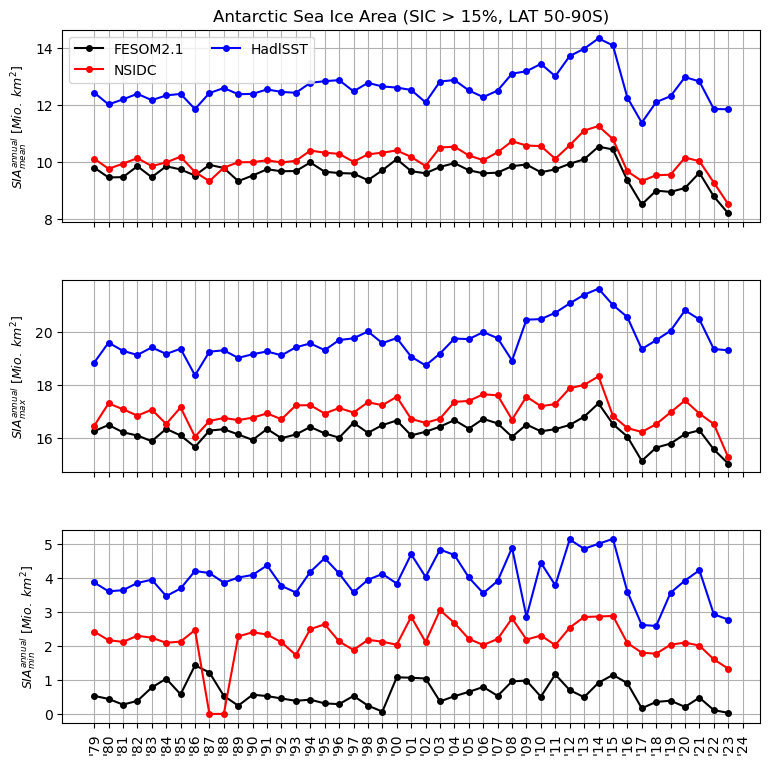

In [57]:
fig, ax = plt.subplots(3,1, figsize=(9,9), sharex=True)

scale = 1e-12 # Mio. km2


# --- FESOM2.1 ---
# Annual Mean
dummy = ice_area_fesom.groupby('time.year').mean()
x = dummy.year
y = dummy * scale

ax[0].plot(x, y, color='k', marker='o', markersize=4, label='FESOM2.1')

# Annual Max.
dummy = ice_area_fesom.groupby('time.year').max()
x = dummy.year
y = dummy * scale

ax[1].plot(x, y, color='k', marker='o', markersize=4,)

# Annual Min.
dummy = ice_area_fesom.groupby('time.year').min()
x = dummy.year
y = dummy * scale

ax[2].plot(x, y, color='k', marker='o', markersize=4,)


# --- NSIDC ---
# Mean
dummy = ice_area_nsidc.groupby('time.year').mean()
x = dummy.year
y = dummy * scale

ax[0].plot(x, y, color='r', marker='o', markersize=4, label='NSIDC')

# Annual Max.
dummy = ice_area_nsidc.groupby('time.year').max()
x = dummy.year
y = dummy * scale

ax[1].plot(x, y, color='r', marker='o', markersize=4,)

# Annual Min.
dummy = ice_area_nsidc.groupby('time.year').min()
x = dummy.year
y = dummy * scale

ax[2].plot(x, y, color='r', marker='o', markersize=4,)

# --- HadlSST ---
# Mean
dummy = ice_area_hadlsst.groupby('time.year').mean()
x = dummy.year
y = dummy * scale

ax[0].plot(x, y, color='b', marker='o', markersize=4, label='HadlSST')

# Annual Max.
dummy = ice_area_hadlsst.groupby('time.year').max()
x = dummy.year
y = dummy * scale

ax[1].plot(x, y, color='b', marker='o', markersize=4,)

# Annual Min.
dummy = ice_area_hadlsst.groupby('time.year').min()
x = dummy.year
y = dummy * scale

ax[2].plot(x, y, color='b', marker='o', markersize=4,)


# --- AXES SETTINGS ---
ax[0].set_title('Antarctic Sea Ice Area (SIC > 15%, LAT 50-90S)')

for axis in ax:
    axis.set_xticks(np.arange(1979,2025))
    axis.set_xticklabels(["'" + str(i)[2:] for i in np.arange(1979,2025)], rotation=90, fontsize=10)
    axis.grid()
    axis.set_xlabel('')

ax[0].legend(ncols=2, fontsize=10)

ax[0].set_ylabel('$SIA^{annual}_{mean}\ [Mio.\ km^2]$', fontsize=9)
ax[1].set_ylabel('$SIA^{annual}_{max}\ [Mio.\ km^2]$', fontsize=9)
ax[2].set_ylabel('$SIA^{annual}_{min}\ [Mio.\ km^2]$', fontsize=9)

plt.subplots_adjust(hspace=.3)



## 2. Ocean Diagnostics

### 2.1 Spatially-Averaged Vertical Profiles (Temp, Salt)

#### Temperature

In [9]:
ds_temp_region = so.fesom_timeseries_of_mean_vertical_profile_in_region(src_path, mesh_diag_path, years=(2011, 2024), box=[-180, 180, -65, -55], varname='temp', log=True)

Box -180E 180E -65N -55N
Found 6967 nodes in the specified box.
[########################################] | 100% Completed | 812.49 ms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2011.nc
[########################################] | 100% Completed | 709.34 ms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2012.nc
[########################################] | 100% Completed | 5.33 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2013.nc
[########################################] | 100% Completed | 5.34 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2014.nc
[########################################] | 100% Completed | 5.44 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2015.nc
[########################################] | 100% Completed | 6.54 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2016.nc
[###

#### Salinity

In [10]:
ds_salt_region = so.fesom_timeseries_of_mean_vertical_profile_in_region(src_path, mesh_diag_path, years=(2011, 2024), box=[-180, 180, -65, -55], varname='salt', log=True)

Box -180E 180E -65N -55N
Found 6967 nodes in the specified box.
[########################################] | 100% Completed | 5.74 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2011.nc
[########################################] | 100% Completed | 5.54 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2012.nc
[########################################] | 100% Completed | 6.04 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2013.nc
[########################################] | 100% Completed | 5.44 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2014.nc
[########################################] | 100% Completed | 5.54 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2015.nc
[########################################] | 100% Completed | 5.54 sms
File loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/salt.fesom.2016.nc
[#####

In [11]:
# --- Remove Climatology ---
# Temp
temp_climatology =  ds_temp_region.groupby('time.month').mean()
temp_anomalies = ds_temp_region.groupby('time.month') - temp_climatology

# Salt
salt_climatology =  ds_salt_region.groupby('time.month').mean()
salt_anomalies = ds_salt_region.groupby('time.month') - salt_climatology

<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
<>:14: SyntaxWarning: invalid escape sequence '\D'
<>:21: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_261520/2502473460.py:14: SyntaxWarning: invalid escape sequence '\D'
  cbar = plt.colorbar(cb, ax=ax[0], label='$\Delta\Theta (\degree C)$')
/tmp/ipykernel_261520/2502473460.py:21: SyntaxWarning: invalid escape sequence '\D'
  cbar = plt.colorbar(cb, ax=ax[1], label='$\Delta S_A (g/kg)$')


Text(0.5, 1.0, 'Anomalous Spatially Averaged Temperature/Salinity Profile (65S - 55S)')

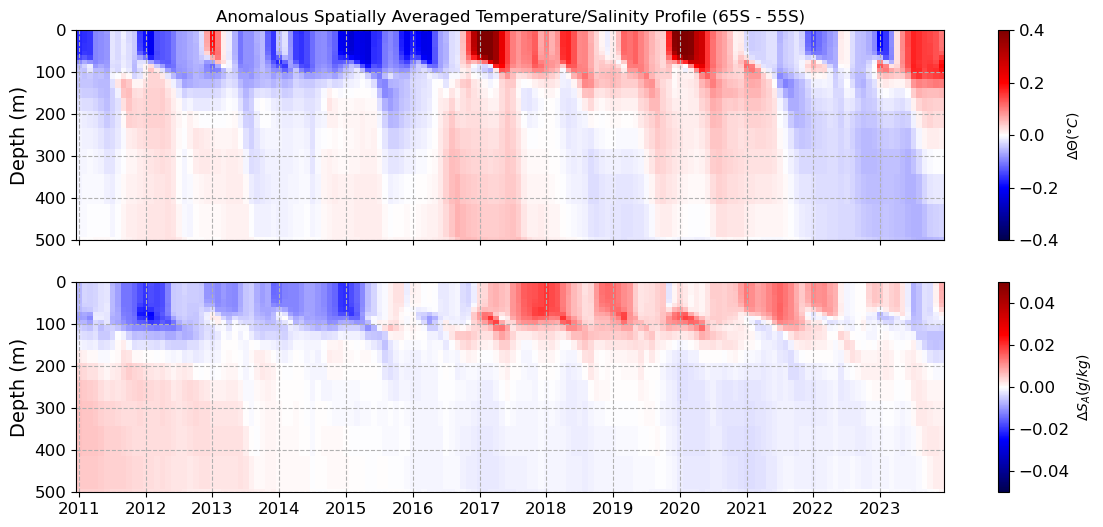

In [14]:
# --- Plot ---
fig, ax = plt.subplots(2,1, figsize=(14,6), sharex=True)

scale = 1
cmap = 'seismic'

x = np.arange(2011, 2024, 1/12)
y = temp_anomalies.nz1.values

# --- Temperature --- #
z = temp_anomalies.temp.values.T * scale

cb = ax[0].pcolormesh(x, y, z, cmap=cmap, vmin=-.4, vmax=.4)
cbar = plt.colorbar(cb, ax=ax[0], label='$\Delta\Theta (\degree C)$')
cbar.ax.tick_params(labelsize=12)

# --- Salinity --- #
z = salt_anomalies.salt.values.T * scale

cb = ax[1].pcolormesh(x, y, z, cmap=cmap, vmin=-.05, vmax=.05)
cbar = plt.colorbar(cb, ax=ax[1], label='$\Delta S_A (g/kg)$')
cbar.ax.tick_params(labelsize=12)

# --- Axis Settings ---
for axis in ax:
    axis.set_ylim((0, 500))
    axis.invert_yaxis()
    axis.grid(linestyle='--')
    axis.set_ylabel('Depth (m)', fontsize=14)
    axis.tick_params(labelsize=12)
    axis.set_xticks(x[::12])

ax[0].set_title('Anomalous Spatially Averaged Temperature/Salinity Profile (65S - 55S)')
#plt.savefig('/albedo/home/fheukamp/PostDoc2/sea_ice_fesom2/plots/coarse_resolution/temp.anom.55Sto65S.2011to2024.png', dpi=500, bbox_inches='tight', transparent=True)

## 3. Spatial Patterns

#### Sea Ice Concentration: Regression

In [6]:
ds_regress_sic_fesom = so.regression2D_fesom(src_path, mesh_diag_path, years=(1979, 2016), box=[-180, 180, -77.5, -45], varname='a_ice', grouping='annual.mean', log=True, depth=None)

Found 21379 nodes in the specified box.
Loading files...
[########################################] | 100% Completed | 3.36 sms
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1979.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1980.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1981.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1982.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1983.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1984.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1985.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1986.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1987.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.1988.nc
Files loaded

In [7]:
ds_regress_sic_nsidc = so.regression2D_nsidc(src_path_nsidc, years=(1979, 2016), box=[-180, 180, -65, -55], depth=None, varname='siconc', grouping='annual.mean', log=True)

Loading files...
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1979.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1980.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1981.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1982.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1983.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1984.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1985.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1986.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1987.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1988.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1989.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1990.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1991.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1992.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc.1993.nc
Files loaded: /work/ab0995/SO-ASE/SIC_NSIDC_V5/siconc

In [8]:
ds_regress_sic_hadleysst = so.regression2D_hadlsst(src_path_hadlsst, years=(1979, 2016), box=[-180, 180, -77.5, -45], depth=None, varname='siconc', grouping='annual.mean', log=True)

Loading files...
[########################################] | 100% Completed | 1.04 sms
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1979.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1980.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1981.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1982.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1983.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1984.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1985.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1986.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1987.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1988.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1989.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1990.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1991.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1992.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1993.nc
Files loaded: /work/ab0995/SO-ASE/HadlSST/siconc.1994.nc


<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:63: SyntaxWarning: invalid escape sequence '\ '
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:39: SyntaxWarning: invalid escape sequence '\ '
<>:63: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_264690/2498962780.py:16: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
/tmp/ipykernel_264690/2498962780.py:39: SyntaxWarning: invalid escape sequence '\ '
  ax[1].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
/tmp/ipykernel_264690/2498962780.py:63: SyntaxWarning: invalid escape sequence '\ '
  ax[2].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


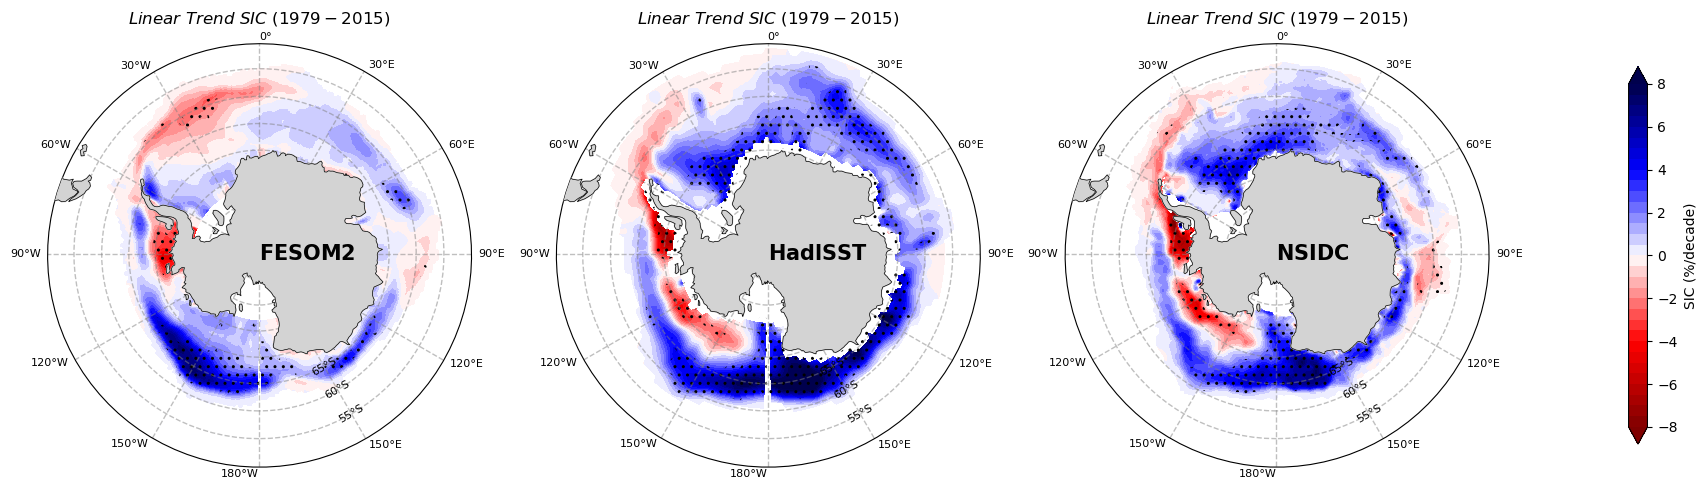

In [37]:
fig, ax = plt.subplots(1,3, figsize=(24,7), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

for axis in ax:
    so.create_map(axis, extent=[-180,180,-90,-50])

#####################################
# --- Sea Ice Concentration Trend ---
#####################################

scale = 10 * 100 # per year to decade & 0.01 to 1%
levels = np.arange(-8,8.5,.5)
cmap = 'seismic_r'

########### FESOM ###############

ax[0].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
x, y = ds_regress_sic_fesom.lon, ds_regress_sic_fesom.lat

###---> Linear Trend
z = ds_regress_sic_fesom.slope.rolling(lon=3, lat=3, center=True).mean().values * scale
z = np.where(z != 0, z, np.nan)
cb = ax[0].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=levels, extend='both')

###---> Significance Hatching
p = ds_regress_sic_fesom.pvalue.values  # assuming this has same shape as z
sig_mask = ma.masked_where(p >= 0.05, p)  # mask where p >= 0.05 (non-significant)

# Apply hatching only where significant
ax[0].contourf(
    x, y, sig_mask, 
    transform=ccrs.PlateCarree(), 
    levels=[0, 0.05],  # dummy levels to trigger hatching
    hatches=[".."], 
    colors="none"
)

########### HadleySST ###############

ax[1].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
x, y = ds_regress_sic_hadleysst.longitude, ds_regress_sic_hadleysst.latitude

###---> Linear Trend
z = ds_regress_sic_hadleysst.slope.rolling(longitude=3, latitude=3, center=True).mean().values.T * scale
z = np.where(z != 0, z, np.nan)
cb = ax[1].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=levels, extend='both')

###---> Significance Hatching
p = ds_regress_sic_hadleysst.pvalue.values.T  # assuming this has same shape as z
sig_mask = ma.masked_where(p >= 0.05, p)  # mask where p >= 0.05 (non-significant)

# Apply hatching only where significant
ax[1].contourf(
    x, y, sig_mask, 
    transform=ccrs.PlateCarree(), 
    levels=[0, 0.05],  # dummy levels to trigger hatching
    hatches=[".."], 
    colors="none"
)


########### NSIDC ###############

ax[2].set_title('$Linear\ Trend\ SIC\ (1979-2015)$')
x, y = ds_regress_sic_nsidc.x, ds_regress_sic_nsidc.y

###---> Linear Trend
z = ds_regress_sic_nsidc.slope * scale #.rolling(longitude=3, latitude=3, center=True).mean().values.T * scale
z = np.where(z != 0, z, np.nan)
cb = ax[2].contourf(x, y, z, transform=ccrs.SouthPolarStereo(), cmap=cmap, levels=levels, extend='both')

###---> Significance Hatching
p = ds_regress_sic_nsidc.pvalue.values.T  # assuming this has same shape as z
sig_mask = ma.masked_where(p >= 0.05, p)  # mask where p >= 0.05 (non-significant)

# Apply hatching only where significant
ax[2].contourf(
    x, y, sig_mask.T, 
    transform=ccrs.SouthPolarStereo(), 
    levels=[0, 0.05],  # dummy levels to trigger hatching
    hatches=[".."], 
    colors="none"
)


########### General ###############
ax[0].text(0,-90, '$\\bf{FESOM2}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)
ax[1].text(0,-90, '$\\bf{HadlSST}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)
ax[2].text(0,-90, '$\\bf{NSIDC}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)
plt.colorbar(cb, ax=ax, label='SIC (%/decade)', pad=.075, shrink=.7)


#### Upper Ocean Temperature (5m Depth): Regression

In [38]:
ds_regress_temp = so.regression2D_fesom(src_path, mesh_diag_path, years=(1979, 2016), box=[-180, 180, -77.5, -45],  depth=5, varname='temp', grouping='annual.mean', grid_data=True, log=True)

Found 21379 nodes in the specified box.
Loading files...
Chosen depth level: 5m
[########################################] | 100% Completed | 34.96 s
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1979.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1980.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1981.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1982.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1983.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1984.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1985.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1986.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1987.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.1988.nc


#### Plot

/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


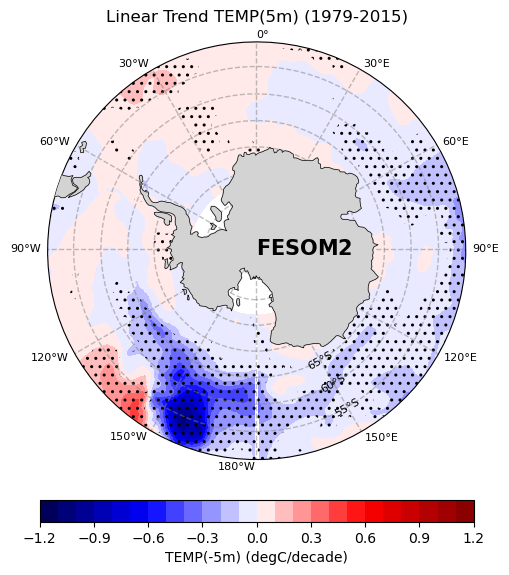

In [43]:
fig, ax = plt.subplots(1, 1, figsize=(8,7), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

for axis in [ax]:
    so.create_map(axis, extent=[-180,180,-90,-50])

scale = 10
cmap = 'seismic_r'

#######################################
# --- Upper Ocean Temperature Trend ---
#######################################

scale = 10
cmap = 'seismic'

#####################################

ax.set_title('Linear Trend TEMP(5m) (1979-2015)')
x, y = ds_regress_temp.lon, ds_regress_temp.lat

###--->Linear Trend
z = ds_regress_temp.slope.rolling(lon=3, lat=3, center=True).mean().values * scale
z = np.where(z != 0, z, np.nan)
cb = ax.contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=np.arange(-1.2, 1.3, 0.1))

###--->Significance Hatching
p = ds_regress_temp.pvalue.values  # assuming this has same shape as z
sig_mask = ma.masked_where(p >= 0.05, p)  # mask where p >= 0.05 (non-significant)

# Apply hatching only where significant
ax.contourf(
    x, y, sig_mask, 
    transform=ccrs.PlateCarree(), 
    levels=[0, 0.05],  # dummy levels to trigger hatching
    hatches=[".."], 
    colors="none",    # no color fill
)


ax.text(0,-90, '$\\bf{FESOM2}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)
plt.colorbar(cb, ax=ax, label='TEMP(-5m) (degC/decade)', pad=.075, shrink=.7, orientation='horizontal')

#### Sea Ice Concentration: Anomalies

In [44]:
ds_anomaly_sic = so.anomaly2D_fesom(src_path, 
                mesh_diag_path,
                ref_period=(2011, 2024),
                box=[-180, 180, -77.5, -45],
                depth=None,
                varname='a_ice',
                grouping='annual.mean',
                grid_data=True,
                log=True
               )

Found 21379 nodes in the specified box.
Loading files...
[########################################] | 100% Completed | 1.82 sms
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2011.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2012.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2013.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2014.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2015.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2016.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2017.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2018.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2019.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/a_ice.fesom.2020.nc
Files loaded

<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\ '
<>:24: SyntaxWarning: invalid escape sequence '\ '
<>:31: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_264690/3502716022.py:16: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_title('$Anomaly\ SIC\ \\bf{2017\ minus\ (2011-2024)}$')
/tmp/ipykernel_264690/3502716022.py:24: SyntaxWarning: invalid escape sequence '\ '
  ax[1].set_title('$Anomaly\ SIC\ \\bf{2020\ minus\ (2011-2024)}$')
/tmp/ipykernel_264690/3502716022.py:31: SyntaxWarning: invalid escape sequence '\D'
  plt.colorbar(cb, ax=ax, label='$\Delta SIC\ (\%)$', pad=.075, shrink=.7)
/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it h

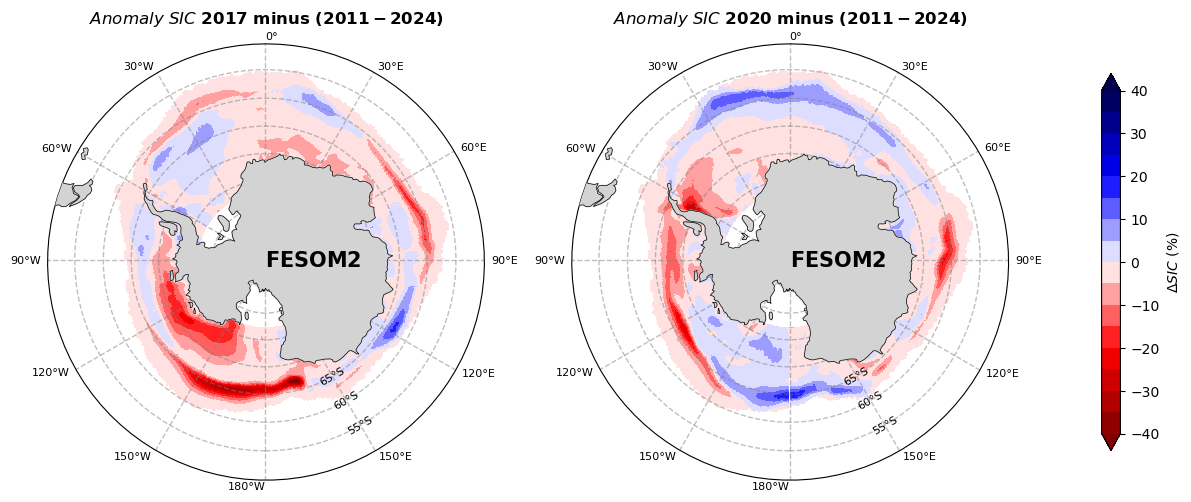

In [52]:
fig, ax = plt.subplots(1,2, figsize=(16,7), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

scale = 100 # 0.1 = 10%
rolling=(3,3) # latxlon window for smoothing
cmap = 'seismic_r'

for axis in ax:
    so.create_map(axis, extent=[-180,180,-90,-50])
    axis.text(0,-90, '$\\bf{FESOM2}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)


#####################################
# --- Sea Ice Concentration Anom ---
#####################################

ax[0].set_title('$Anomaly\ SIC\ \\bf{2017\ minus\ (2011-2024)}$')
x, y = ds_anomaly_sic.lon, ds_anomaly_sic.lat

z = ds_anomaly_sic.a_ice.sel(year=2017).rolling(lon=rolling[1], lat=rolling[0], center=True).mean().values * scale
z = np.where(z == 0, np.nan, z)

cb = ax[0].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=np.arange(-40, 45, 5), extend='both')

ax[1].set_title('$Anomaly\ SIC\ \\bf{2020\ minus\ (2011-2024)}$')

z = ds_anomaly_sic.a_ice.sel(year=2020).rolling(lon=rolling[1], lat=rolling[0], center=True).mean().values * scale
z = np.where(z == 0, np.nan, z)

cb = ax[1].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=np.arange(-40, 45, 5), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta SIC\ (\%)$', pad=.075, shrink=.7)

#### Upper Ocean Temperature (5m Depth): Anomalies

In [45]:
ds_anomaly_temp = so.anomaly2D_fesom(src_path, 
                mesh_diag_path,
                ref_period=(2011, 2024),
                box=[-180, 180, -77.5, -45],
                depth=5,
                varname='temp',
                grouping='annual.mean',
                grid_data=True,
                log=True
               )

Found 21379 nodes in the specified box.
Loading files...
Chosen depth level: 5m
[########################################] | 100% Completed | 8.27 ss
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2011.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2012.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2013.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2014.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2015.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2016.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2017.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2018.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2019.nc
Files loaded: /work/ab0995/a270186/model_simulations/fesom2/ARC01/temp.fesom.2020.nc


<>:15: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\D'
<>:15: SyntaxWarning: invalid escape sequence '\ '
<>:23: SyntaxWarning: invalid escape sequence '\ '
<>:29: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_264690/644015962.py:15: SyntaxWarning: invalid escape sequence '\ '
  ax[0].set_title('$Anomaly\ TEMP(5m)\ \\bf{2017\ minus\ (2011-2024)}$')
/tmp/ipykernel_264690/644015962.py:23: SyntaxWarning: invalid escape sequence '\ '
  ax[1].set_title('$Anomaly\ TEMP(5m)\ \\bf{2020\ minus\ (2011-2024)}$')
/tmp/ipykernel_264690/644015962.py:29: SyntaxWarning: invalid escape sequence '\D'
  plt.colorbar(cb, ax=ax, label='$\Delta TEMP(5m)\ (\%)$', pad=.075, shrink=.7)
/home/a/a270186/.conda/envs/so_ase/lib/python3.13/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no ef

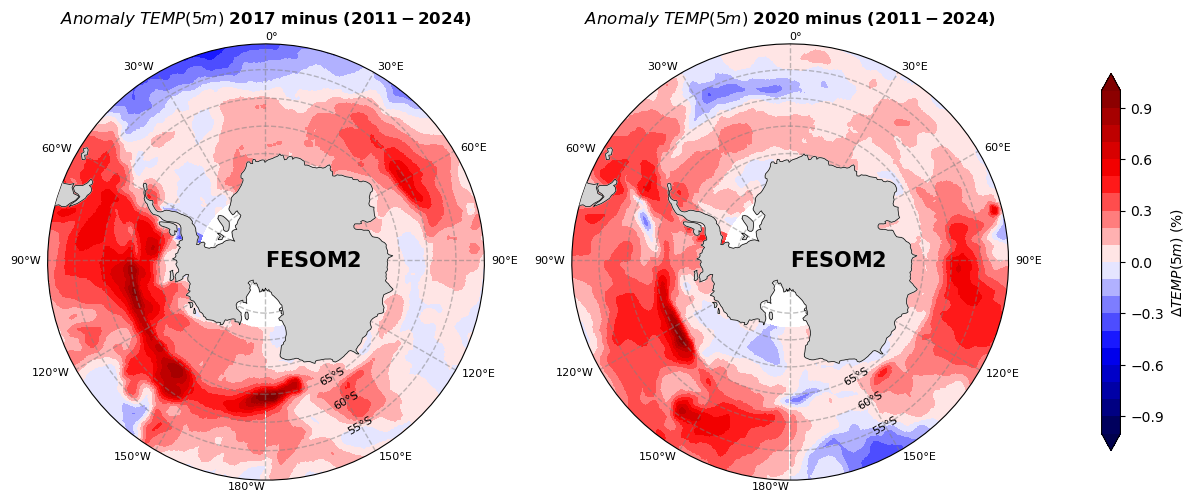

In [51]:
fig, ax = plt.subplots(1,2, figsize=(16,7), subplot_kw=dict(projection=ccrs.SouthPolarStereo()))

scale = 1 # scale for conversion
rolling=(3,3) # latxlon window for smoothing
cmap = 'seismic'

for axis in ax:
    so.create_map(axis, extent=[-180,180,-90,-50])
    axis.text(0,-90, '$\\bf{FESOM2}$', transform=ccrs.PlateCarree(), ha='left', va='center', fontsize=15, zorder=1e5)

#####################################
# --- Ocean Temperature Anomaly 5m ---
#####################################

ax[0].set_title('$Anomaly\ TEMP(5m)\ \\bf{2017\ minus\ (2011-2024)}$')
x, y = ds_anomaly_temp.lon, ds_anomaly_temp.lat

z = ds_anomaly_temp.temp.sel(year=2017).rolling(lon=rolling[1], lat=rolling[0], center=True).mean().values * scale

cb = ax[0].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=np.arange(-1, 1.1, .1), extend='both')


ax[1].set_title('$Anomaly\ TEMP(5m)\ \\bf{2020\ minus\ (2011-2024)}$')

z = ds_anomaly_temp.temp.sel(year=2020).rolling(lon=rolling[1], lat=rolling[0], center=True).mean().values * scale

cb = ax[1].contourf(x, y, z, transform=ccrs.PlateCarree(), cmap=cmap, levels=np.arange(-1, 1.1, .1), extend='both')

plt.colorbar(cb, ax=ax, label='$\Delta TEMP(5m)\ (\%)$', pad=.075, shrink=.7)